# CEMIL Aggregator Training Workflow

This notebook provides a complete pipeline to **train** the Contextual Attention Based Efficient MIL (CEMIL) aggregator. It utilizes an Instructor-Learner framework as proposed in the CEMIL paper.

### Architecture & Framework:
1.  **Gated Contextual Attention**: Enhances standard attention by incorporating a trainable context vector with a gating mechanism, multiplying the patch hidden representations.
2.  **Serial Training (Knowledge Distillation)**:
    - **Instructor**: Trains on all patches in a bag.
    - **Learner**: Trains only on the top-k patches selected by the Instructor's attention scores, utilizing a combined loss (Cross-Entropy, Patch Representation Loss, and Prediction Probability KL Divergence).

**Configuration (from TransMIL):**
- **Feature reduction**: 1024 -> 512 dimensions.
- **Optimizer**: Lookahead optimizer (with Adam base, lr=2e-4, weight_decay=1e-5).
- **Batch Size**: 1.

**Data Labeling:**
- **LUAD**: Class 0
- **LUSC**: Class 1

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import pandas as pd
import numpy as np
import os
import collections
from sklearn.metrics import roc_auc_score, accuracy_score, confusion_matrix, roc_curve
import matplotlib.pyplot as plt
from pathlib import Path
from tqdm.auto import tqdm

# Device setup
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"[INFO] Operating on: {device}")

[INFO] Operating on: cuda


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## 0. Define Paths and Configuration

We set up the root directory and specific paths for CSVs and features.
**Labels are mapped**: `luad` -> 0, `lusc` -> 1.

In [ ]:
# Paths
root_path = '/content/drive/MyDrive/CS231/split/'
save_path = '/content/CS231/aggregator_methods/'

# Feature folders (containing .pt files)
train_feat_dir = Path(root_path) / 'train'
val_feat_dir = Path(root_path) / 'val'
test_feat_dir = Path(root_path) / 'test'

# CSV index files
train_csv_file = Path(root_path) / 'train.csv'
val_csv_file = Path(root_path) / 'val.csv'
test_csv_file = Path(root_path) / 'test.csv'

# Map labels to integers
LABEL_MAP = {'luad': 0, 'lusc': 1}

# Output paths
output_base = Path(save_path) / 'CEMIL'
checkpoints_path = output_base / 'checkpoints' / 'v1.0'
logs_path = output_base / 'logs' / 'v1.0'
checkpoints_path.mkdir(parents=True, exist_ok=True)
logs_path.mkdir(parents=True, exist_ok=True)

print(f"[INFO] Label Mapping: {LABEL_MAP}")

[INFO] Label Mapping: {'luad': 0, 'lusc': 1}


## 1. Custom Dataset for .pt Feature Loading

The `BagDataset` class reads from the index CSV files. It loads the binary `.pt` files using `torch.load`.

In [ ]:
class BagDataset(Dataset):
    def __init__(self, csv_file, feat_dir, label_map):
        self.df = pd.read_csv(csv_file)
        self.feat_dir = feat_dir
        self.label_map = label_map

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        feat_filename = row['filename']
        feat_path = self.feat_dir / feat_filename

        # Load binary features using torch.load
        feats = torch.load(feat_path, map_location='cpu')

        # Ensure float type and handle potential extra dimensions
        if not isinstance(feats, torch.Tensor):
            feats = torch.tensor(feats)

        feats = feats.float()

        # Load label
        label_str = str(row['label']).lower()
        label = torch.tensor(self.label_map[label_str]).long()

        return feats, label

# Initialize Datasets
if train_csv_file.exists():
    train_ds = BagDataset(train_csv_file, train_feat_dir, LABEL_MAP)
    val_ds = BagDataset(val_csv_file, val_feat_dir, LABEL_MAP)
    test_ds = BagDataset(test_csv_file, test_feat_dir, LABEL_MAP)

    print("\n--- DATASET SUMMARY ---")
    print(f"Training Bags:   {len(train_ds)}")
    print(f"Validation Bags: {len(val_ds)}")
    print(f"Testing Bags:    {len(test_ds)}")
    print("------------------------\n")
else:
    print("[ERROR] Index CSV files not found. Please check paths.")


--- DATASET SUMMARY ---
Training Bags:   669
Validation Bags: 143
Testing Bags:    144
------------------------



## 2. CEMIL Architecture & Lookahead Optimizer

We implement the Gated CEMIL aggregator and the Lookahead optimizer wrapper based on TransMIL configs.

In [ ]:
class CEMIL(nn.Module):
    def __init__(self, input_size, hidden_size=512, output_class=2):
        super(CEMIL, self).__init__()
        # Patch Representation Module (PRM)
        self.prm = nn.Sequential(
            nn.Linear(input_size, hidden_size),
            nn.ReLU()
        )

        # Contextual Attention Module (CAM) - Gated variant
        self.context_mod = nn.Parameter(torch.ones(1, hidden_size))
        self.attention_V = nn.Linear(hidden_size, 128)
        self.attention_U = nn.Linear(hidden_size, 128)
        self.attention_weights = nn.Linear(128, 1)

        # Classification block
        self.classifier = nn.Linear(hidden_size, output_class)

    def forward(self, x):
        # x: (N patches, input_size)
        h = self.prm(x) # (N, hidden_size)

        # Multiplicative context modification
        h_prime = h * self.context_mod

        # Gated attention
        A_V = torch.tanh(self.attention_V(h_prime))
        A_U = torch.sigmoid(self.attention_U(h_prime))
        A = self.attention_weights(A_V * A_U) # (N, 1)
        A = torch.softmax(A, dim=0) # (N, 1)

        # Aggregation
        z = torch.sum(A * h, dim=0, keepdim=True) # (1, hidden_size)
        logits = self.classifier(z) # (1, output_class)

        return logits, A, h

class Lookahead(torch.optim.Optimizer):
    """Lookahead Optimizer Wrapper"""
    def __init__(self, optimizer, k=5, alpha=0.5):
        self.optimizer = optimizer
        self.k = k
        self.alpha = alpha
        self.param_groups = self.optimizer.param_groups
        self.state = collections.defaultdict(dict)
        self.fast_state = self.optimizer.state
        for group in self.param_groups:
            group["counter"] = 0

    def update(self, group):
        for fast in group["params"]:
            param_state = self.state[fast]
            if "slow_param" not in param_state:
                param_state["slow_param"] = torch.clone(fast.data).detach()
            slow = param_state["slow_param"]
            slow += (fast.data - slow) * self.alpha
            fast.data.copy_(slow)

    def update_lookahead(self):
        for group in self.param_groups:
            self.update(group)

    def step(self, closure=None):
        loss = self.optimizer.step(closure)
        for group in self.param_groups:
            if group["counter"] == 0:
                for fast in group["params"]:
                    param_state = self.state[fast]
                    param_state["slow_param"] = torch.clone(fast.data).detach()
            group["counter"] += 1
            if group["counter"] >= self.k:
                group["counter"] = 0
                self.update(group)
        return loss

    def zero_grad(self, set_to_none=False):
        self.optimizer.zero_grad(set_to_none=set_to_none)

# --- CONFIGURATION ---
NUM_CLASSES = 2 # LUAD (0), LUSC (1)

try:
    sample_bag, _ = train_ds[0]
    FEATS_SIZE = sample_bag.shape[1]
    print(f"[INFO] Dynamically detected FEATS_SIZE: {FEATS_SIZE}")
except:
    FEATS_SIZE = 1024
    print(f"[INFO] Detection failed, using fallback FEATS_SIZE: {FEATS_SIZE}")

print("\n--- INSTRUCTOR MODEL ARCHITECTURE SUMMARY ---")
dummy_model = CEMIL(FEATS_SIZE, hidden_size=512, output_class=NUM_CLASSES)
for name, param in dummy_model.named_parameters():
    if param.requires_grad:
        print(f"{name:40} | Shape: {str(list(param.shape)):15} | Params: {param.numel()}")
print(f"Total Trainable Parameters: {sum(p.numel() for p in dummy_model.parameters() if p.requires_grad)}")
print("-------------------------------------------\n")

[INFO] Dynamically detected FEATS_SIZE: 1024

--- INSTRUCTOR MODEL ARCHITECTURE SUMMARY ---
context_mod                              | Shape: [1, 512]        | Params: 512
prm.0.weight                             | Shape: [512, 1024]     | Params: 524288
prm.0.bias                               | Shape: [512]           | Params: 512
attention_V.weight                       | Shape: [128, 512]      | Params: 65536
attention_V.bias                         | Shape: [128]           | Params: 128
attention_U.weight                       | Shape: [128, 512]      | Params: 65536
attention_U.bias                         | Shape: [128]           | Params: 128
attention_weights.weight                 | Shape: [1, 128]        | Params: 128
attention_weights.bias                   | Shape: [1]             | Params: 1
classifier.weight                        | Shape: [2, 512]        | Params: 1024
classifier.bias                          | Shape: [2]             | Params: 2
Total Trainable Paramete

## 3. Shape Analysis (Visualizing Data Flow)

Verifying the flow of a single bag through the model.

In [ ]:
def print_tensor_flow(model, num_patches=300):
    dummy_input = torch.randn(num_patches, FEATS_SIZE).to(device)
    print(f"Input Bag: {num_patches} patches, {FEATS_SIZE} features/patch")
    model = model.to(device)

    with torch.no_grad():
        logits, A, h = model(dummy_input)
        print(f"Shape 2 [Patch Representations h]: {h.shape}")
        print(f"Shape 3 [Attention weights A]:     {A.shape}")
        print(f"Shape 4 [Final Score]:             {logits.shape}")

print_tensor_flow(dummy_model)

Input Bag: 300 patches, 1024 features/patch
Shape 2 [Patch Representations h]: torch.Size([300, 512])
Shape 3 [Attention weights A]:     torch.Size([300, 1])
Shape 4 [Final Score]:             torch.Size([1, 2])


## 4. Evaluation Function

In [ ]:
def evaluate(model, loader, is_learner=False, instructor=None, k_ratio=0.6):
    model.eval()
    if instructor:
        instructor.eval()

    all_probs, all_labels = [], []
    with torch.no_grad():
        for bag, label in loader:
            bag = bag.squeeze(0).to(device)

            if is_learner and instructor is not None:
                # Get attention from instructor
                _, A_I, _ = instructor(bag)
                num_patches = bag.shape[0]
                k_patches = max(1, int(num_patches * k_ratio))
                _, top_indices = torch.topk(A_I.squeeze(), k_patches)
                bag = bag[top_indices]

            logits, _, _ = model(bag)
            probs = torch.softmax(logits, dim=1)
            all_probs.append(probs.cpu().numpy())
            all_labels.append(label.item())

    probs = np.concatenate(all_probs, axis=0)
    preds = np.argmax(probs, axis=1)
    acc = accuracy_score(all_labels, preds)
    auc = roc_auc_score(all_labels, probs[:, 1])
    return acc, auc, all_labels, probs

## 5. Training Phase 1: Instructor

We first train the Instructor network on all patches using Cross-Entropy.


==================== STARTING INSTRUCTOR TRAINING (200 Epochs) ====================


Instructor Ep 01/200:   0%|          | 0/669 [00:00<?, ?it/s]

[EPOCH 01] Loss: 0.6902 | Val Acc: 0.6014 | Val AUC: 0.7731
  >> Best Instructor saved (AUC: 0.7731)


Instructor Ep 02/200:   0%|          | 0/669 [00:00<?, ?it/s]

[EPOCH 02] Loss: 0.6639 | Val Acc: 0.5315 | Val AUC: 0.7883
  >> Best Instructor saved (AUC: 0.7883)


...

[EPOCH 198] Loss: 0.0006 | Val Acc: 0.8392 | Val AUC: 0.9253


Instructor Ep 199/200:   0%|          | 0/669 [00:00<?, ?it/s]

[EPOCH 199] Loss: 0.0006 | Val Acc: 0.8392 | Val AUC: 0.9253


Instructor Ep 200/200:   0%|          | 0/669 [00:00<?, ?it/s]

[EPOCH 200] Loss: 0.0006 | Val Acc: 0.8392 | Val AUC: 0.9253

==================== INSTRUCTOR TRAINING COMPLETE ====================


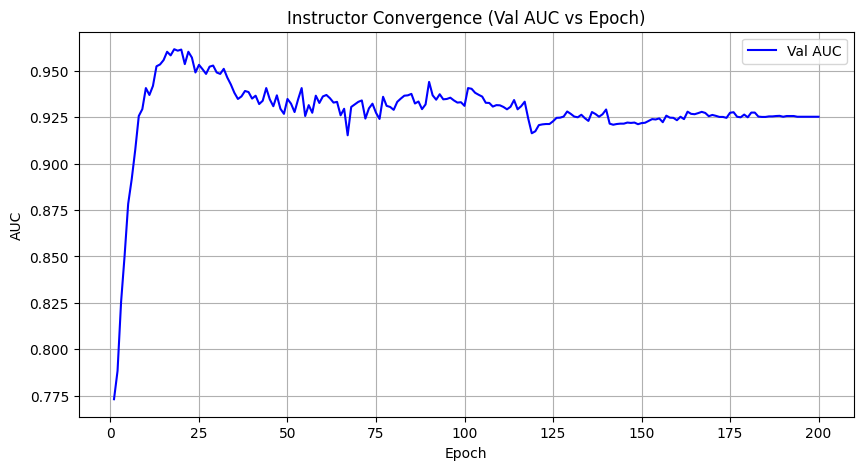

In [ ]:
EPOCHS = 200
if 'train_ds' in locals():
    train_loader = DataLoader(train_ds, batch_size=1, shuffle=True)
    val_loader = DataLoader(val_ds, batch_size=1, shuffle=False)

    instructor = CEMIL(FEATS_SIZE, hidden_size=512, output_class=NUM_CLASSES).to(device)
    criterion = nn.CrossEntropyLoss()
    base_opt_I = torch.optim.Adam(instructor.parameters(), lr=2e-4, weight_decay=1e-5)
    optimizer_I = Lookahead(base_opt_I, k=5, alpha=0.5)
    scheduler_I = torch.optim.lr_scheduler.CosineAnnealingLR(base_opt_I, T_max=EPOCHS)

    history_I = {'epoch': [], 'train_loss': [], 'val_acc': [], 'val_auc': []}
    best_auc_I = 0

    print(f"\n{'='*20} STARTING INSTRUCTOR TRAINING ({EPOCHS} Epochs) {'='*20}")

    for epoch in range(EPOCHS):
        instructor.train()
        epoch_loss = 0
        pbar = tqdm(train_loader, desc=f"Instructor Ep {epoch+1:02d}/{EPOCHS}", leave=False)

        for bag, label in pbar:
            optimizer_I.zero_grad()
            bag, label = bag.squeeze(0).to(device), label.to(device)

            logits, _, _ = instructor(bag)
            loss = criterion(logits, label)
            loss.backward()
            optimizer_I.step()

            epoch_loss += loss.item()
            pbar.set_postfix({'loss': f"{loss.item():.4f}"})

        val_acc, val_auc, _, _ = evaluate(instructor, val_loader)
        avg_loss = epoch_loss / len(train_loader)

        history_I['epoch'].append(epoch + 1)
        history_I['train_loss'].append(avg_loss)
        history_I['val_acc'].append(val_acc)
        history_I['val_auc'].append(val_auc)

        scheduler_I.step()
        print(f"[EPOCH {epoch+1:02d}] Loss: {avg_loss:.4f} | Val Acc: {val_acc:.4f} | Val AUC: {val_auc:.4f}")

        if val_auc > best_auc_I:
            best_auc_I = val_auc
            torch.save(instructor.state_dict(), checkpoints_path / 'instructor_best.pth')
            print(f"  >> Best Instructor saved (AUC: {best_auc_I:.4f})")

    pd.DataFrame(history_I).to_csv(logs_path / 'instructor_history.csv', index=False)
    print(f"\n{'='*20} INSTRUCTOR TRAINING COMPLETE {'='*20}")

    # Plot Convergence Diagram (Instructor)
    plt.figure(figsize=(10, 5))
    plt.plot(history_I['epoch'], history_I['val_auc'], label='Val AUC', color='blue')
    plt.xlabel('Epoch')
    plt.ylabel('AUC')
    plt.title('Instructor Convergence (Val AUC vs Epoch)')
    plt.legend()
    plt.grid(True)
    plt.show()

## 6. Training Phase 2: Learner (Serial Distillation)

We load the best Instructor, freeze it, and use it to distill knowledge to the Learner. The Learner is trained on only the top `k_ratio` patches per bag.

[INFO] ONLY PRM weights transferred from Instructor to Learner successfully.

==================== STARTING LEARNER TRAINING (200 Epochs) ====================


Learner Ep 01/200:   0%|          | 0/669 [00:00<?, ?it/s]

[EPOCH 01] Loss: 0.3057 | Val Acc: 0.8322 | Val AUC: 0.9169
  >> Best Learner saved (AUC: 0.9169)


Learner Ep 02/200:   0%|          | 0/669 [00:00<?, ?it/s]

[EPOCH 02] Loss: 0.1904 | Val Acc: 0.8042 | Val AUC: 0.9219
  >> Best Learner saved (AUC: 0.9219)


...

[EPOCH 198] Loss: 0.0560 | Val Acc: 0.8811 | Val AUC: 0.9554


Learner Ep 199/200:   0%|          | 0/669 [00:00<?, ?it/s]

[EPOCH 199] Loss: 0.0560 | Val Acc: 0.8811 | Val AUC: 0.9554


Learner Ep 200/200:   0%|          | 0/669 [00:00<?, ?it/s]

[EPOCH 200] Loss: 0.0560 | Val Acc: 0.8811 | Val AUC: 0.9554

==================== LEARNER TRAINING COMPLETE ====================


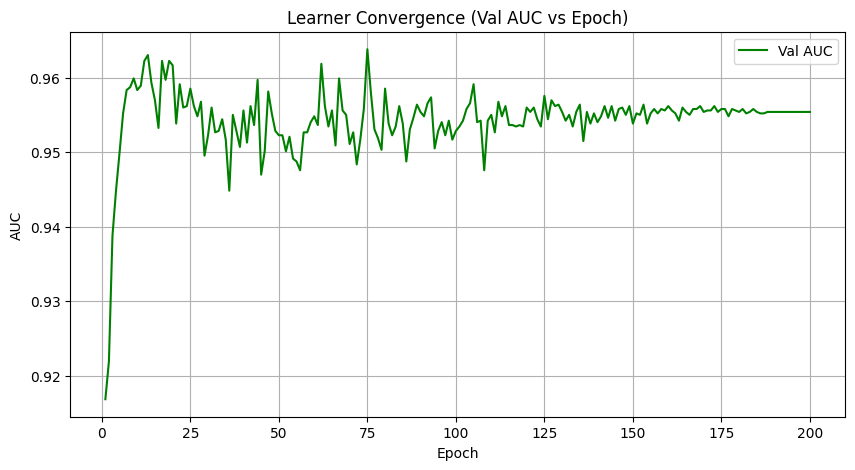

In [ ]:
if 'train_ds' in locals():
    # Load best instructor and freeze
    instructor.load_state_dict(torch.load(checkpoints_path / 'instructor_best.pth', map_location=device))
    instructor.eval()
    for param in instructor.parameters():
        param.requires_grad = False

    # Initialize learner and transfer ONLY PRM weights from Instructor
    learner = CEMIL(FEATS_SIZE, hidden_size=512, output_class=NUM_CLASSES).to(device)
    instructor_state = torch.load(checkpoints_path / 'instructor_best.pth', map_location=device)

    # Filter for PRM weights only
    prm_state = {k: v for k, v in instructor_state.items() if k.startswith('prm.')}
    learner.load_state_dict(prm_state, strict=False)
    print("[INFO] ONLY PRM weights transferred from Instructor to Learner successfully.")

    base_opt_L = torch.optim.Adam(learner.parameters(), lr=2e-4, weight_decay=1e-5)
    optimizer_L = Lookahead(base_opt_L, k=5, alpha=0.5)
    scheduler_L = torch.optim.lr_scheduler.CosineAnnealingLR(base_opt_L, T_max=EPOCHS)

    k_ratio = 0.6
    lambda1 = 0.3 # Patch Representation loss weight
    lambda2 = 0.3 # Prediction Probability loss weight

    history_L = {'epoch': [], 'train_loss': [], 'val_acc': [], 'val_auc': []}
    best_auc_L = 0

    print(f"\n{'='*20} STARTING LEARNER TRAINING ({EPOCHS} Epochs) {'='*20}")
    for epoch in range(EPOCHS):
        learner.train()
        epoch_loss = 0
        pbar = tqdm(train_loader, desc=f"Learner Ep {epoch+1:02d}/{EPOCHS}", leave=False)

        for bag, label in pbar:
            bag, label = bag.squeeze(0).to(device), label.to(device)

            # 1. Instructor Forward & Patch Selection
            with torch.no_grad():
                logits_I, A_I, h_I = instructor(bag)
                probs_I = torch.softmax(logits_I, dim=1)

                num_patches = bag.shape[0]
                k_patches = max(1, int(num_patches * k_ratio))
                _, top_indices = torch.topk(A_I.squeeze(), k_patches)
                bag_learner = bag[top_indices]
                h_I_top = h_I[top_indices]

            # 2. Learner Forward
            optimizer_L.zero_grad()
            logits_L, A_L, h_L = learner(bag_learner)
            probs_L = torch.softmax(logits_L, dim=1)

            # 3. Compute Composite Loss
            loss_ce = criterion(logits_L, label)
            loss_pr = F.mse_loss(h_L, h_I_top)

            log_probs_L = torch.log(probs_L + 1e-8)
            loss_pp = F.kl_div(log_probs_L, probs_I, reduction='batchmean')

            loss = lambda1 * loss_pr + lambda2 * loss_pp + (1 - lambda1 - lambda2) * loss_ce

            loss.backward()
            optimizer_L.step()

            epoch_loss += loss.item()
            pbar.set_postfix({'loss': f"{loss.item():.4f}"})

        val_acc, val_auc, _, _ = evaluate(learner, val_loader, is_learner=True, instructor=instructor, k_ratio=k_ratio)
        avg_loss = epoch_loss / len(train_loader)

        history_L['epoch'].append(epoch + 1)
        history_L['train_loss'].append(avg_loss)
        history_L['val_acc'].append(val_acc)
        history_L['val_auc'].append(val_auc)

        scheduler_L.step()
        print(f"[EPOCH {epoch+1:02d}] Loss: {avg_loss:.4f} | Val Acc: {val_acc:.4f} | Val AUC: {val_auc:.4f}")

        if val_auc > best_auc_L:
            best_auc_L = val_auc
            torch.save(learner.state_dict(), checkpoints_path / 'learner_best.pth')
            print(f"  >> Best Learner saved (AUC: {best_auc_L:.4f})")

    pd.DataFrame(history_L).to_csv(logs_path / 'learner_history.csv', index=False)
    print(f"\n{'='*20} LEARNER TRAINING COMPLETE {'='*20}")

    # Plot Convergence Diagram (Learner)
    plt.figure(figsize=(10, 5))
    plt.plot(history_L['epoch'], history_L['val_auc'], label='Val AUC', color='green')
    plt.xlabel('Epoch')
    plt.ylabel('AUC')
    plt.title('Learner Convergence (Val AUC vs Epoch)')
    plt.legend()
    plt.grid(True)
    plt.show()

## 7. Final Evaluation & ROC (Learner)

Testing the final distilled Learner model.


--- FINAL TEST PERFORMANCE (Gated-CEMIL Learner) ---
Accuracy: 0.8472
AUC:      0.9275

Confusion Matrix:
[[63  9]
 [13 59]]

LUAD (0) - Accuracy: 0.8750
LUSC (1) - Accuracy: 0.8194


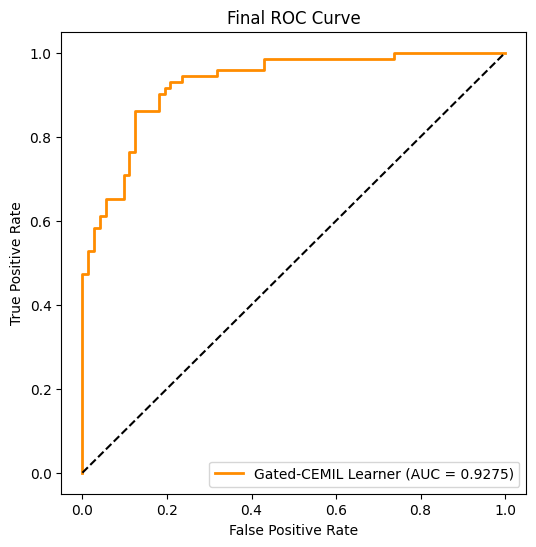

In [ ]:
if 'test_ds' in locals():
    test_loader = DataLoader(test_ds, batch_size=1, shuffle=False)
    learner.load_state_dict(torch.load(checkpoints_path / 'learner_best.pth', map_location=device))

    acc, auc, y_true, y_probs = evaluate(learner, test_loader, is_learner=True, instructor=instructor, k_ratio=k_ratio)

    print("\n--- FINAL TEST PERFORMANCE (Gated-CEMIL Learner) ---")
    print(f"Accuracy: {acc:.4f}")
    print(f"AUC:      {auc:.4f}")

    cm = confusion_matrix(y_true, np.argmax(y_probs, axis=1))
    print("\nConfusion Matrix:")
    print(cm)
    print(f"\nLUAD (0) - Accuracy: {cm[0,0]/sum(cm[0]):.4f}" if sum(cm[0])>0 else "")
    print(f"LUSC (1) - Accuracy: {cm[1,1]/sum(cm[1]):.4f}" if sum(cm[1])>0 else "")

    fpr, tpr, _ = roc_curve(y_true, y_probs[:, 1])
    plt.figure(figsize=(6, 6))
    plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'Gated-CEMIL Learner (AUC = {auc:.4f})')
    plt.plot([0, 1], [0, 1], 'k--')
    plt.xlabel('False Positive Rate'); plt.ylabel('True Positive Rate'); plt.legend()
    plt.title('Final ROC Curve')
    plt.show()